<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tangb\AppData\Local\Temp\ipykernel_4456\3440304087.py:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')


                단계    유저수    전환율  이전단계대비
0        1. 설치한 유저  90189  100.0     NaN
1   2. 1라운드 이상 플레이  86195   95.6    95.6
2  3. 10라운드 이상 플레이  55952   62.0    64.9
3        4. D1 리텐션  40153   44.5    71.8
4        5. D7 리텐션  16781   18.6    41.8


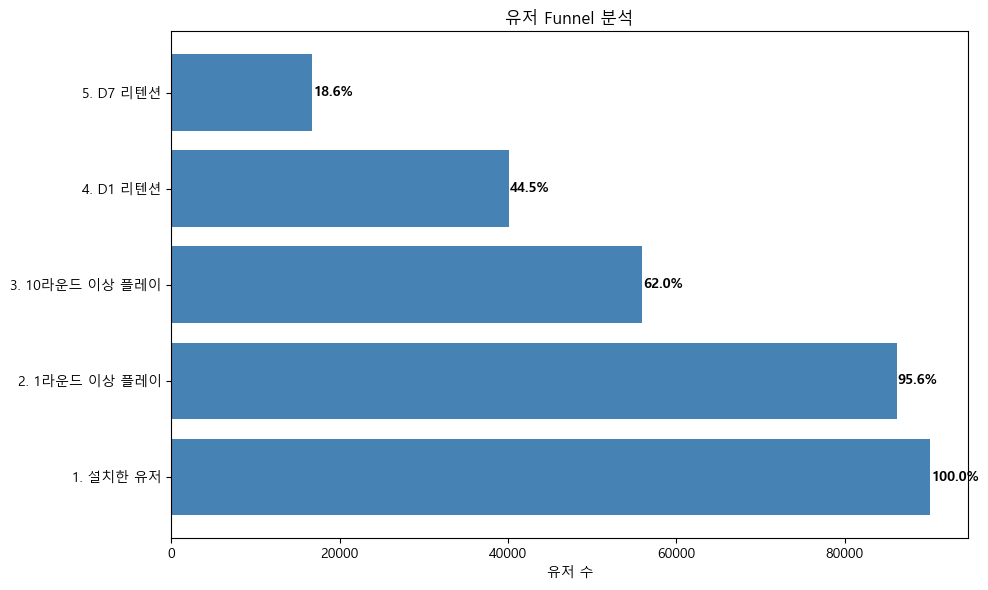

          총유저수  D1리텐션  D7리텐션   평균라운드
version                             
gate_30  44700  0.448  0.190  52.456
gate_40  45489  0.442  0.182  51.299


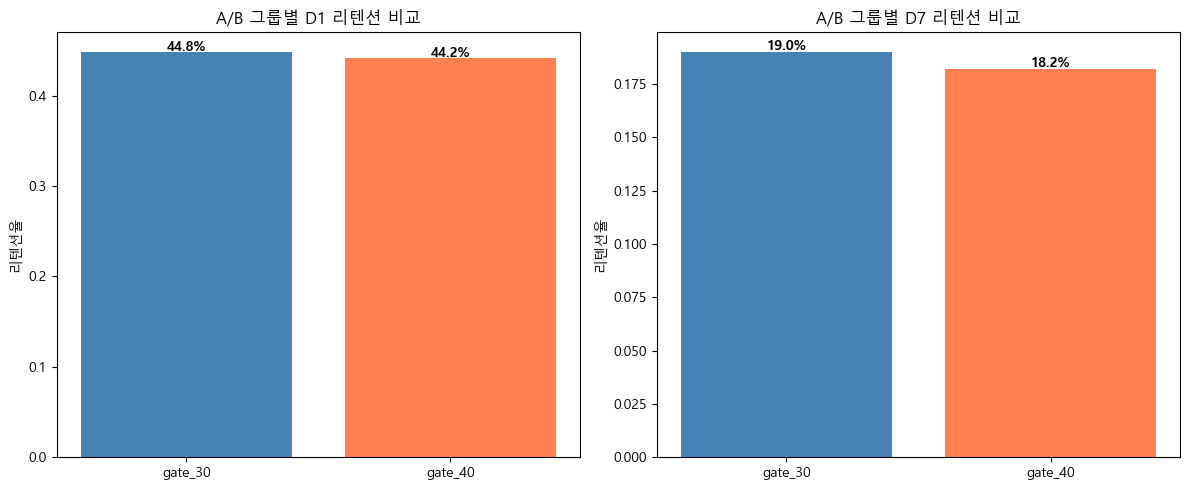

In [1]:
# 02_funnel_analysis.ipynb

# =====================
# 1. 라이브러리 로드
# =====================
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')

# =====================
# 2. Funnel 단계 정의
# =====================
total = len(df)

funnel = {
    '1. 설치한 유저': total,
    '2. 1라운드 이상 플레이': (df['sum_gamerounds'] >= 1).sum(),
    '3. 10라운드 이상 플레이': (df['sum_gamerounds'] >= 10).sum(),
    '4. D1 리텐션': df['retention_1'].sum(),
    '5. D7 리텐션': df['retention_7'].sum(),
}

funnel_df = pd.DataFrame({
    '단계': list(funnel.keys()),
    '유저수': list(funnel.values())
})

funnel_df['전환율'] = (funnel_df['유저수'] / total * 100).round(1)
funnel_df['이전단계대비'] = (
    funnel_df['유저수'] / funnel_df['유저수'].shift(1) * 100
).round(1)

print(funnel_df)

# =====================
# 3. Funnel 시각화
# =====================
plt.figure(figsize=(10, 6))
bars = plt.barh(funnel_df['단계'], funnel_df['유저수'], color='steelblue')
plt.xlabel('유저 수')
plt.title('유저 Funnel 분석')

for bar, rate in zip(bars, funnel_df['전환율']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{rate}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/funnel_chart.png')  # 깃허브용 저장
plt.show()

# =====================
# 4. A/B 그룹별 Funnel 비교
# =====================
ab_funnel = df.groupby('version').agg(
    총유저수=('userid', 'count'),
    D1리텐션=('retention_1', 'mean'),
    D7리텐션=('retention_7', 'mean'),
    평균라운드=('sum_gamerounds', 'mean')
).round(3)

print(ab_funnel)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(ab_funnel.index, ab_funnel['D1리텐션'],
            color=['steelblue', 'coral'])
axes[0].set_title('A/B 그룹별 D1 리텐션 비교')
axes[0].set_ylabel('리텐션율')
for i, v in enumerate(ab_funnel['D1리텐션']):
    axes[0].text(i, v + 0.001, f'{v:.1%}', ha='center', fontweight='bold')

axes[1].bar(ab_funnel.index, ab_funnel['D7리텐션'],
            color=['steelblue', 'coral'])
axes[1].set_title('A/B 그룹별 D7 리텐션 비교')
axes[1].set_ylabel('리텐션율')
for i, v in enumerate(ab_funnel['D7리텐션']):
    axes[1].text(i, v + 0.001, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/ab_retention_compare.png')  # 깃허브용 저장
plt.show()